# EDA 20: Basket Size / Items Per Order Analysis

This notebook analyzes basket size, items per order, how basket size changes over time, whether it differs during promotion periods, and whether it helps explain revenue variation.

Forecast-feature examples are leakage-safe: any lagged or rolling basket-size feature is shifted so date `t` only uses information before date `t`.

## 1. Setup and file discovery

Required and optional CSV files are located recursively from the current working directory. Missing files are reported clearly and dependent analysis continues where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
REQUIRED_FILES = ["orders.csv", "order_items.csv"]
OPTIONAL_FILES = ["promotions.csv", "products.csv", "payments.csv"]
ALL_FILES = REQUIRED_FILES + OPTIONAL_FILES

def normalize_name(value):
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())

def display_warning(message):
    print(f"WARNING: {message}")

def find_csv_files(root, filenames):
    all_csvs = list(root.rglob("*.csv"))
    found = {}
    for filename in filenames:
        target = normalize_name(filename)
        matches = [p for p in all_csvs if normalize_name(p.name) == target]
        matches = sorted(matches, key=lambda p: (len(p.parts), str(p).lower()))
        found[filename] = matches[0] if matches else None
    return found

file_paths = find_csv_files(ROOT, ALL_FILES)
discovery_table = pd.DataFrame(
    {
        "file": list(file_paths.keys()),
        "path": [str(p) if p is not None else None for p in file_paths.values()],
        "required": [name in REQUIRED_FILES for name in file_paths.keys()],
        "status": ["found" if p is not None else "missing" for p in file_paths.values()],
    }
)
display(discovery_table)

for name in REQUIRED_FILES:
    if file_paths.get(name) is None:
        display_warning(f"Required file {name} was not found. Dependent analysis will continue where possible.")
for name in OPTIONAL_FILES:
    if file_paths.get(name) is None:
        print(f"Note: Optional file {name} was not found. Optional analysis using it will be skipped.")

,file,path,required,status
0,orders.csv,D:\Code\Datathon 2026\datathon-2026-round-1\or...,True,found
1,order_items.csv,D:\Code\Datathon 2026\datathon-2026-round-1\or...,True,found
2,promotions.csv,D:\Code\Datathon 2026\datathon-2026-round-1\pr...,False,found
3,products.csv,D:\Code\Datathon 2026\datathon-2026-round-1\pr...,False,found
4,payments.csv,D:\Code\Datathon 2026\datathon-2026-round-1\pa...,False,found


## 2. Load orders, order_items, and optional files

Available CSVs are loaded safely with pandas. Column names and sample rows are displayed to make schema assumptions visible.

In [2]:
def safe_read_csv(path):
    if path is None:
        return None
    attempts = [
        {"low_memory": False},
        {"encoding": "utf-8-sig", "low_memory": False},
        {"encoding": "latin1", "low_memory": False},
    ]
    last_error = None
    for kwargs in attempts:
        try:
            return pd.read_csv(path, **kwargs)
        except Exception as exc:
            last_error = exc
    display_warning(f"Could not load {path}: {last_error}")
    return None

data = {name: safe_read_csv(path) for name, path in file_paths.items()}
orders = data.get("orders.csv")
order_items = data.get("order_items.csv")
promotions = data.get("promotions.csv")
products = data.get("products.csv")
payments = data.get("payments.csv")

load_summary = []
for name, df in data.items():
    load_summary.append(
        {
            "file": name,
            "loaded": df is not None,
            "rows": 0 if df is None else len(df),
            "columns": 0 if df is None else df.shape[1],
        }
    )
display(pd.DataFrame(load_summary))

for name, df in data.items():
    if df is not None:
        print(f"\n{name} columns:")
        print(list(df.columns))
        display(df.head())

,file,loaded,rows,columns
0,orders.csv,True,646945,8
1,order_items.csv,True,714669,7
2,promotions.csv,True,50,10
3,products.csv,True,2412,8
4,payments.csv,True,646945,4



orders.csv columns:
['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign



order_items.csv columns:
['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,"1,138.2200",0.0000,NaN,NaN
1,2,609,7,"10,166.2500",0.0000,NaN,NaN
2,3,396,3,"11,220.3300",0.0000,NaN,NaN
3,4,635,5,"10,639.2500",0.0000,NaN,NaN
4,6,1935,1,"1,597.8400",0.0000,NaN,NaN


...

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0000,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0000,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0000,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0000,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0000,2013-07-30,2013-09-02,Streetwear,online,0,150000



products.csv columns:
['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,"11,059.6500","9,704.8429"
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,"9,523.0760","5,393.8703"
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,"15,951.6332","11,371.9193"
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,"15,753.7173","8,573.1730"
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,"15,766.3345","14,063.5704"



payments.csv columns:
['order_id', 'payment_method', 'payment_value', 'installments']


,order_id,payment_method,payment_value,installments
0,1,credit_card,"7,967.5400",3
1,2,cod,"71,163.7500",1
2,3,credit_card,"33,660.9900",3
3,4,credit_card,"53,196.2500",3
4,6,paypal,"1,597.8400",1


## 3. Identify key, date, quantity, revenue, promotion, and category columns

Column identification uses normalized names, numeric plausibility, date parse quality, and join-key overlap. If item quantity is not available, basket size falls back to item-line count per order.

In [3]:
def score_column(col, include_terms=None, exclude_terms=None):
    n = normalize_name(col)
    score = 0
    include_terms = include_terms or []
    exclude_terms = exclude_terms or []
    for term, points in include_terms:
        if normalize_name(term) in n:
            score += points
    for term, points in exclude_terms:
        if normalize_name(term) in n:
            score -= points
    return score

def choose_column_by_terms(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = [(score_column(col, include_terms, exclude_terms), col) for col in df.columns]
    scored = sorted(scored, key=lambda x: (x[0], -len(str(x[1]))), reverse=True)
    return scored[0][1] if scored and scored[0][0] >= min_score else None

def choose_numeric_column(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = []
    for col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        valid_rate = numeric.notna().mean()
        if valid_rate < 0.5 or numeric.nunique(dropna=True) < 2:
            continue
        score = score_column(col, include_terms, exclude_terms) + valid_rate * 3
        scored.append((score, col))
    scored = sorted(scored, reverse=True)
    return scored[0][1] if scored and scored[0][0] >= min_score else None

def choose_date_column(df, preferred_terms=None):
    if df is None or df.empty:
        return None
    preferred_terms = preferred_terms or []
    candidates = []
    for col in df.columns:
        parsed = pd.to_datetime(df[col], errors="coerce")
        valid_rate = parsed.notna().mean()
        unique_count = parsed.nunique(dropna=True)
        name_score = score_column(
            col,
            preferred_terms + [("date", 10), ("time", 4), ("order", 5), ("start", 5), ("end", 5), ("created", 4)],
            [("id", 8), ("zip", 8), ("price", 8), ("amount", 8), ("quantity", 8), ("qty", 8), ("value", 6)],
        )
        if valid_rate >= 0.45 and unique_count >= 1:
            candidates.append((valid_rate * 100 + name_score + min(unique_count, 100) * 0.01, col))
    candidates = sorted(candidates, reverse=True)
    return candidates[0][1] if candidates else None

def choose_common_key(left_df, right_df, left_terms, right_terms=None):
    if left_df is None or right_df is None:
        return None, None
    right_terms = right_terms or left_terms
    left_candidates = [
        col for col in left_df.columns
        if score_column(col, left_terms, [("date", 5), ("amount", 5), ("price", 5), ("quantity", 5), ("qty", 5)]) > 0
    ]
    right_candidates = [
        col for col in right_df.columns
        if score_column(col, right_terms, [("date", 5), ("amount", 5), ("price", 5), ("quantity", 5), ("qty", 5)]) > 0
    ]
    best = None
    for lcol in left_candidates:
        lvals = left_df[lcol].dropna().astype(str)
        if lvals.empty:
            continue
        lsample = set(lvals.head(10000))
        for rcol in right_candidates:
            rvals = right_df[rcol].dropna().astype(str)
            if rvals.empty:
                continue
            rsample = set(rvals.head(10000))
            overlap = len(lsample.intersection(rsample))
            score = overlap + score_column(lcol, left_terms) + score_column(rcol, right_terms)
            if best is None or score > best[0]:
                best = (score, lcol, rcol, overlap)
    if best is None or best[0] <= 0:
        return None, None
    return best[1], best[2]

order_terms = [("orderid", 14), ("order", 8), ("invoice", 6), ("transaction", 6), ("receipt", 4)]
product_terms = [("productid", 14), ("product", 8), ("sku", 6), ("itemid", 8), ("item", 4)]
promo_terms = [("promoid", 14), ("promo", 10), ("campaign", 9), ("promotion", 9), ("coupon", 6), ("offer", 5)]

order_id_col = choose_column_by_terms(orders, order_terms, [("date", 6), ("amount", 4), ("status", 3)], min_score=4)
order_date_col = choose_date_column(orders, [("orderdate", 16), ("order", 8)])
item_order_col, order_order_col_for_items = choose_common_key(order_items, orders, order_terms)
payment_order_col, order_order_col_for_payments = choose_common_key(payments, orders, order_terms) if payments is not None else (None, None)
item_product_col, product_product_col = choose_common_key(order_items, products, product_terms) if products is not None else (None, None)

quantity_col = choose_numeric_column(order_items, [("quantity", 10), ("qty", 10), ("units", 6)], [("id", 10), ("price", 6), ("amount", 4)], min_score=5)
price_col = choose_numeric_column(order_items, [("unitprice", 12), ("price", 10), ("sellingprice", 10), ("saleprice", 10)], [("id", 10), ("cost", 8), ("discount", 8), ("quantity", 8), ("qty", 8)], min_score=5)
discount_col = choose_numeric_column(order_items, [("discount", 10), ("promo", 3)], [("id", 5), ("quantity", 8), ("qty", 8), ("price", 5)], min_score=5)
direct_item_revenue_col = choose_numeric_column(
    order_items,
    [("revenue", 12), ("sales", 10), ("total", 8), ("subtotal", 6), ("net", 6)],
    [("discount", 10), ("price", 8), ("cost", 8), ("quantity", 10), ("qty", 10), ("id", 10)],
    min_score=5,
)
payment_amount_col = choose_numeric_column(
    payments,
    [("paymentvalue", 14), ("paymentamount", 12), ("amount", 9), ("value", 8), ("paid", 6), ("total", 6)],
    [("id", 8), ("installment", 8), ("quantity", 8), ("qty", 8)],
    min_score=5,
) if payments is not None else None
category_col = choose_column_by_terms(products, [("category", 12), ("department", 8), ("class", 6), ("segment", 4)], [("id", 8), ("price", 6), ("cost", 6)], min_score=6) if products is not None else None
item_promo_cols = [col for col in order_items.columns if score_column(col, promo_terms, [("date", 6), ("amount", 5)]) >= 6] if order_items is not None else []
promo_start_col = choose_date_column(promotions, [("startdate", 16), ("start", 10)]) if promotions is not None else None
promo_end_col = choose_date_column(promotions, [("enddate", 16), ("end", 10)]) if promotions is not None else None

detected = pd.DataFrame(
    [
        {"field": "orders.order_id", "column": order_id_col},
        {"field": "orders.order_date", "column": order_date_col},
        {"field": "order_items.order_id", "column": item_order_col},
        {"field": "payments.order_id", "column": payment_order_col},
        {"field": "order_items.product_id", "column": item_product_col},
        {"field": "products.product_id", "column": product_product_col},
        {"field": "order_items.quantity", "column": quantity_col},
        {"field": "order_items.price", "column": price_col},
        {"field": "order_items.discount", "column": discount_col},
        {"field": "order_items.direct_revenue", "column": direct_item_revenue_col},
        {"field": "payments.payment_amount", "column": payment_amount_col},
        {"field": "products.category", "column": category_col},
        {"field": "order_items.promotion_columns", "column": ", ".join(item_promo_cols) if item_promo_cols else None},
        {"field": "promotions.start_date", "column": promo_start_col},
        {"field": "promotions.end_date", "column": promo_end_col},
    ]
)
display(detected)

required_ready = True
if orders is None or order_items is None:
    display_warning("orders.csv and order_items.csv are required for basket-size analysis.")
    required_ready = False
if order_id_col is None or item_order_col is None:
    display_warning("Could not identify order ID fields for orders and order_items.")
    required_ready = False
if order_date_col is None:
    display_warning("Could not identify order date.")
    required_ready = False
if quantity_col is None:
    print("Note: Quantity column was not identified. Basket size will fall back to item-line count per order.")
if direct_item_revenue_col is None and not (quantity_col is not None and price_col is not None) and payment_amount_col is None:
    display_warning("Could not identify or infer revenue from item price/quantity or payments. Revenue relationship sections will be limited.")
if not item_promo_cols and discount_col is None and (promo_start_col is None or promo_end_col is None):
    print("Note: Promotion status is unavailable. Basket size by promotion status will be skipped.")

,field,column
0,orders.order_id,order_id
1,orders.order_date,order_date
2,order_items.order_id,order_id
3,payments.order_id,order_id
4,order_items.product_id,product_id
5,products.product_id,product_id
6,order_items.quantity,quantity
7,order_items.price,unit_price
8,order_items.discount,discount_amount
9,order_items.direct_revenue,None


## 4. Build order-level basket dataset

Order items are aggregated by order ID to calculate basket quantity, item-line count, unique product count, revenue, promotion flags, and optional category mix.

In [4]:
order_level = pd.DataFrame()
items_work = pd.DataFrame()
category_order = pd.DataFrame()
basket_metric_col = "basket_size_quantity"
basket_metric_label = "total item quantity per order"
promo_status_available = False

if required_ready:
    orders_work = orders.copy()
    orders_work["_order_id"] = orders_work[order_id_col].astype(str)
    orders_work["order_date"] = pd.to_datetime(orders_work[order_date_col], errors="coerce")
    order_level = orders_work[["_order_id", "order_date"]].drop_duplicates("_order_id").copy()

    items_work = order_items.copy()
    items_work["_order_id"] = items_work[item_order_col].astype(str)
    if item_product_col is not None:
        items_work["_product_id"] = items_work[item_product_col].astype(str)
    else:
        items_work["_product_id"] = np.arange(len(items_work)).astype(str)

    if quantity_col is not None:
        items_work["item_quantity"] = pd.to_numeric(items_work[quantity_col], errors="coerce")
        basket_metric_col = "basket_size_quantity"
        basket_metric_label = f"sum of item quantity from {quantity_col}"
    else:
        items_work["item_quantity"] = 1
        basket_metric_col = "basket_size_lines"
        basket_metric_label = "fallback item-line count per order because quantity was unavailable"

    if direct_item_revenue_col is not None:
        items_work["item_revenue"] = pd.to_numeric(items_work[direct_item_revenue_col], errors="coerce")
    elif quantity_col is not None and price_col is not None:
        qty = pd.to_numeric(items_work[quantity_col], errors="coerce")
        price = pd.to_numeric(items_work[price_col], errors="coerce")
        discount = pd.to_numeric(items_work[discount_col], errors="coerce").fillna(0) if discount_col is not None else 0
        items_work["item_revenue"] = qty * price
    else:
        items_work["item_revenue"] = np.nan

    promo_flags = []
    for col in item_promo_cols:
        if col in items_work.columns:
            promo_flags.append(items_work[col].notna())
    if discount_col is not None:
        promo_flags.append(pd.to_numeric(items_work[discount_col], errors="coerce").fillna(0) > 0)
    if promo_flags:
        items_work["has_item_promo"] = np.logical_or.reduce(promo_flags)
        promo_status_available = True
    else:
        items_work["has_item_promo"] = False

    item_agg = items_work.groupby("_order_id", as_index=False).agg(
        basket_size_quantity=("item_quantity", "sum"),
        basket_size_lines=("item_quantity", "size"),
        unique_products_per_order=("_product_id", "nunique"),
        order_revenue_from_items=("item_revenue", "sum"),
        has_item_promo=("has_item_promo", "max"),
        missing_quantity_rows=("item_quantity", lambda s: s.isna().sum()),
    )
    order_level = order_level.merge(item_agg, on="_order_id", how="left")

    if payments is not None and payment_order_col is not None and payment_amount_col is not None:
        payments_work = payments.copy()
        payments_work["_order_id"] = payments_work[payment_order_col].astype(str)
        payments_work["payment_amount"] = pd.to_numeric(payments_work[payment_amount_col], errors="coerce")
        payment_agg = payments_work.groupby("_order_id", as_index=False).agg(payment_amount=("payment_amount", "sum"), payment_records=("payment_amount", "size"))
        order_level = order_level.merge(payment_agg, on="_order_id", how="left")

    if "payment_amount" in order_level.columns:
        order_level["order_revenue"] = order_level["order_revenue_from_items"].where(order_level["order_revenue_from_items"].notna(), order_level["payment_amount"])
    else:
        order_level["order_revenue"] = order_level["order_revenue_from_items"]

    if promotions is not None and promo_start_col is not None and promo_end_col is not None:
        promos = promotions.copy()
        promos["_promo_start"] = pd.to_datetime(promos[promo_start_col], errors="coerce")
        promos["_promo_end"] = pd.to_datetime(promos[promo_end_col], errors="coerce")
        valid_promos = promos.dropna(subset=["_promo_start", "_promo_end"]).copy()
        order_level["in_promotion_calendar_window"] = False
        if not valid_promos.empty:
            order_dates = order_level["order_date"]
            promo_flag = pd.Series(False, index=order_level.index)
            for promo_start, promo_end in valid_promos[["_promo_start", "_promo_end"]].itertuples(index=False, name=None):
                promo_flag = promo_flag | ((order_dates >= promo_start) & (order_dates <= promo_end))
            order_level["in_promotion_calendar_window"] = promo_flag.fillna(False)
            promo_status_available = True
    else:
        order_level["in_promotion_calendar_window"] = False

    order_level["has_item_promo"] = order_level["has_item_promo"].fillna(False).astype(bool)
    order_level["is_promo_order"] = order_level["has_item_promo"] | order_level["in_promotion_calendar_window"].fillna(False).astype(bool)
    order_level[basket_metric_col] = pd.to_numeric(order_level[basket_metric_col], errors="coerce")
    order_level["AOV"] = order_level["order_revenue"] / 1

    if products is not None and item_product_col is not None and product_product_col is not None and category_col is not None:
        products_work = products.copy()
        products_work["_product_id"] = products_work[product_product_col].astype(str)
        category_items = items_work.merge(products_work[["_product_id", category_col]].drop_duplicates("_product_id"), on="_product_id", how="left", indicator="_product_join")
        category_items[category_col] = category_items[category_col].fillna("Unknown").astype(str)
        category_order = category_items.groupby(["_order_id", category_col], as_index=False).agg(
            category_revenue=("item_revenue", "sum"),
            category_quantity=("item_quantity", "sum"),
            category_lines=("item_quantity", "size"),
        )
        category_order = category_order.merge(
            order_level[["_order_id", basket_metric_col, "basket_size_lines", "unique_products_per_order", "order_revenue", "is_promo_order"]],
            on="_order_id",
            how="left",
        )

    print(f"Basket-size definition used: {basket_metric_label}")
    display(order_level.head(10))
else:
    display_warning("Skipping order-level basket dataset construction because required keys were unavailable.")

Basket-size definition used: sum of item quantity from quantity


,_order_id,order_date,basket_size_quantity,basket_size_lines,unique_products_per_order,order_revenue_from_items,has_item_promo,missing_quantity_rows,payment_amount,payment_records,order_revenue,in_promotion_calendar_window,is_promo_order,AOV
0,1,2012-07-04,7,1,1,"7,967.5400",False,0,"7,967.5400",1,"7,967.5400",False,False,"7,967.5400"
1,2,2012-07-04,7,1,1,"71,163.7500",False,0,"71,163.7500",1,"71,163.7500",False,False,"71,163.7500"
2,3,2012-07-04,3,1,1,"33,660.9900",False,0,"33,660.9900",1,"33,660.9900",False,False,"33,660.9900"
3,4,2012-07-04,5,1,1,"53,196.2500",False,0,"53,196.2500",1,"53,196.2500",False,False,"53,196.2500"
4,6,2012-07-06,1,1,1,"1,597.8400",False,0,"1,597.8400",1,"1,597.8400",False,False,"1,597.8400"
5,7,2012-07-06,6,1,1,"9,800.9400",False,0,"9,800.9400",1,"9,800.9400",False,False,"9,800.9400"
6,8,2012-07-06,10,2,2,"16,187.5600",False,0,"16,187.5600",1,"16,187.5600",False,False,"16,187.5600"
7,9,2012-07-06,8,1,1,"32,397.1200",False,0,"32,397.1200",1,"32,397.1200",False,False,"32,397.1200"
8,10,2012-07-06,5,1,1,"19,886.8500",False,0,"19,886.8500",1,"19,886.8500",False,False,"19,886.8500"
9,13,2012-07-06,6,1,1,"36,037.6800",False,0,"36,037.6800",1,"36,037.6800",False,False,"36,037.6800"


## 5. Join and aggregation quality checks

Validate item-to-order matching, orders without items, missing quantities, duplicated order IDs, and zero/negative basket sizes.

In [5]:
quality = {}

if not order_level.empty:
    order_ids = set(order_level["_order_id"].dropna().astype(str))
    item_ids = order_items[item_order_col].dropna().astype(str) if order_items is not None and item_order_col is not None else pd.Series(dtype=str)
    item_rows_matched = int(item_ids.isin(order_ids).sum()) if not item_ids.empty else np.nan
    item_rows_unmatched = int((~item_ids.isin(order_ids)).sum()) if not item_ids.empty else np.nan

    quality = {
        "number_of_orders": len(order_level),
        "duplicated_order_ids_in_orders": int(orders[order_id_col].duplicated().sum()) if orders is not None and order_id_col is not None else np.nan,
        "order_items_rows": len(order_items) if order_items is not None else np.nan,
        "order_items_rows_matched_to_orders": item_rows_matched,
        "order_items_rows_unmatched_to_orders": item_rows_unmatched,
        "orders_without_item_rows": int(order_level["basket_size_lines"].isna().sum()),
        "orders_with_missing_quantity_rows": int(order_level["missing_quantity_rows"].fillna(0).gt(0).sum()) if "missing_quantity_rows" in order_level.columns else np.nan,
        "orders_with_zero_or_negative_basket_size": int((order_level[basket_metric_col].fillna(0) <= 0).sum()),
        "orders_with_missing_revenue": int(order_level["order_revenue"].isna().sum()),
        "orders_with_zero_or_negative_revenue": int((order_level["order_revenue"].fillna(0) <= 0).sum()),
        "promotion_status_available": promo_status_available,
        "basket_size_definition": basket_metric_label,
    }
    display(pd.DataFrame([quality]).T.rename(columns={0: "value"}))
else:
    display_warning("Join quality checks skipped because order-level basket data is unavailable.")

,value
number_of_orders,646945
duplicated_order_ids_in_orders,0
order_items_rows,714669
order_items_rows_matched_to_orders,714669
order_items_rows_unmatched_to_orders,0
orders_without_item_rows,0
orders_with_missing_quantity_rows,0
orders_with_zero_or_negative_basket_size,0
orders_with_missing_revenue,0
orders_with_zero_or_negative_revenue,0


## 6. Basket size summary

Summarize average, median, percentiles, unique products, item lines, and extreme basket sizes.

In [6]:
basket_summary = {}
common_basket_sizes = pd.DataFrame()
valid_baskets = pd.DataFrame()

if not order_level.empty:
    valid_baskets = order_level.dropna(subset=[basket_metric_col]).copy()
    basket_values = valid_baskets[basket_metric_col]
    large_basket_threshold = max(basket_values.quantile(0.99), basket_values.quantile(0.75) + 1.5 * (basket_values.quantile(0.75) - basket_values.quantile(0.25)))
    basket_summary = {
        "basket_size_definition": basket_metric_label,
        "orders_with_basket_size": len(valid_baskets),
        "average_items_per_order": basket_values.mean(),
        "median_items_per_order": basket_values.median(),
        "std_items_per_order": basket_values.std(),
        "min_items_per_order": basket_values.min(),
        "p25_items_per_order": basket_values.quantile(0.25),
        "p75_items_per_order": basket_values.quantile(0.75),
        "p90_items_per_order": basket_values.quantile(0.90),
        "p95_items_per_order": basket_values.quantile(0.95),
        "p99_items_per_order": basket_values.quantile(0.99),
        "max_items_per_order": basket_values.max(),
        "average_unique_products_per_order": valid_baskets["unique_products_per_order"].mean(),
        "average_item_lines_per_order": valid_baskets["basket_size_lines"].mean(),
        "large_basket_threshold_used": large_basket_threshold,
    }
    display(pd.DataFrame([basket_summary]).T.rename(columns={0: "value"}))

    common_basket_sizes = basket_values.round(0).astype("Int64").value_counts().sort_index().rename_axis("basket_size").reset_index(name="orders")
    common_basket_sizes["order_share"] = common_basket_sizes["orders"] / common_basket_sizes["orders"].sum()
    display(common_basket_sizes.head(30))

    print("Very large baskets:")
    display(valid_baskets.sort_values(basket_metric_col, ascending=False)[["_order_id", "order_date", basket_metric_col, "basket_size_lines", "unique_products_per_order", "order_revenue", "is_promo_order"]].head(15))
    print("Very small baskets:")
    display(valid_baskets.sort_values(basket_metric_col, ascending=True)[["_order_id", "order_date", basket_metric_col, "basket_size_lines", "unique_products_per_order", "order_revenue", "is_promo_order"]].head(15))
else:
    display_warning("Basket size summary skipped because order-level basket data is unavailable.")

,value
basket_size_definition,sum of item quantity from quantity
orders_with_basket_size,646945
average_items_per_order,4.9666
median_items_per_order,5.0000
std_items_per_order,2.7898
min_items_per_order,1
p25_items_per_order,3.0000
p75_items_per_order,7.0000
p90_items_per_order,8.0000
p95_items_per_order,9.0000


,basket_size,orders,order_share
0,1,72900,0.1127
1,2,73709,0.1139
2,3,74474,0.1151
3,4,75399,0.1165
4,5,76973,0.1190
5,6,77879,0.1204
6,7,78696,0.1216
7,8,79085,0.1222
8,9,8260,0.0128
9,10,7237,0.0112


Very large baskets:


,_order_id,order_date,basket_size_quantity,basket_size_lines,unique_products_per_order,order_revenue,is_promo_order
461054,594591,2018-05-30,31,5,5,"121,587.7500",False
62008,79991,2013-05-26,27,4,4,"42,526.8300",False
453781,585205,2018-05-09,26,4,4,"139,286.1000",False
139815,180502,2014-05-19,25,4,4,"44,451.2500",False
25178,32586,2012-12-01,25,4,4,"28,554.7000",False
193037,249048,2015-01-31,24,4,4,"32,606.3600",True
187451,241805,2014-12-29,24,3,3,"35,664.7200",True
166814,215223,2014-08-30,24,3,3,"81,055.6000",True
265223,342038,2015-11-27,24,4,4,"18,404.5300",True
204401,263667,2015-03-31,24,4,4,"58,771.2900",True


Very small baskets:


,_order_id,order_date,basket_size_quantity,basket_size_lines,unique_products_per_order,order_revenue,is_promo_order
72937,94091,2013-06-29,1,1,1,"6,311.2300",True
72947,94104,2013-07-03,1,1,1,"5,324.5800",True
72957,94116,2013-07-01,1,1,1,921.8800,True
72958,94118,2013-07-02,1,1,1,"1,556.2100",True
646944,834397,2022-12-31,1,1,1,"4,716.7500",True
4,6,2012-07-06,1,1,1,"1,597.8400",False
11,16,2012-07-05,1,1,1,"5,074.1500",False
29,36,2012-07-05,1,1,1,"3,514.8000",False
73011,94180,2013-07-02,1,1,1,"4,785.1400",True
73014,94188,2013-07-01,1,1,1,"5,873.0700",True


## 7. Items per order distribution

A histogram and frequency table show the basket-size distribution. The chart is capped at the 99th percentile for readability while the true maximum is reported above.

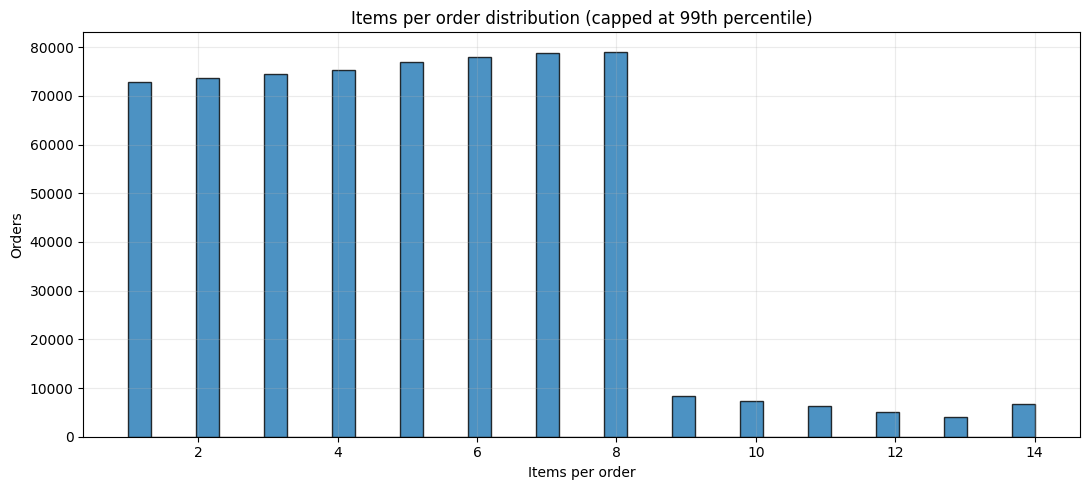

,basket_size,orders,order_share
7,8,79085,0.1222
6,7,78696,0.1216
5,6,77879,0.1204
4,5,76973,0.1190
3,4,75399,0.1165
2,3,74474,0.1151
1,2,73709,0.1139
0,1,72900,0.1127
8,9,8260,0.0128
9,10,7237,0.0112


In [7]:
if not valid_baskets.empty:
    cap_value = max(1, valid_baskets[basket_metric_col].quantile(0.99))
    plot_values = valid_baskets[basket_metric_col].clip(upper=cap_value)
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.hist(plot_values, bins=40, edgecolor="black", alpha=0.8)
    ax.set_title("Items per order distribution (capped at 99th percentile)")
    ax.set_xlabel("Items per order")
    ax.set_ylabel("Orders")
    plt.tight_layout()
    plt.show()

    top_common = common_basket_sizes.sort_values("orders", ascending=False).head(15)
    display(top_common)
else:
    display_warning("Items per order distribution skipped because basket data is unavailable.")

## 8. Basket size over time

Daily basket size is tracked with 7-day and 30-day rolling means to identify periods where basket size increases or decreases.

,date,order_count,total_revenue,avg_items_per_order,median_items_per_order,avg_unique_products_per_order,total_items,large_basket_share,AOV,month_of_year,quarter,dayofweek,weekday_name,basket_roll_mean_7_descriptive,basket_roll_mean_30_descriptive
0,2012-07-04,162,"5,123,547.9400",4.7963,5.0000,1.0741,777,0.0000,"31,626.8391",7,3,2,Wednesday,NaN,NaN
1,2012-07-05,97,"2,751,773.4500",4.4124,4.0000,1.0619,428,0.0103,"28,368.7985",7,3,3,Thursday,NaN,NaN
2,2012-07-06,93,"3,054,029.4200",4.7419,5.0000,1.0645,441,0.0000,"32,839.0260",7,3,4,Friday,4.6502,NaN
3,2012-07-07,73,"2,667,930.9400",4.9863,5.0000,1.0274,364,0.0000,"36,546.9992",7,3,5,Saturday,4.7342,NaN
4,2012-07-08,88,"2,360,851.9000",4.4773,4.0000,1.0682,394,0.0000,"26,827.8625",7,3,6,Sunday,4.6828,NaN
5,2012-07-09,137,"3,548,386.4600",5.3285,5.0000,1.1460,730,0.0073,"25,900.6311",7,3,0,Monday,4.7904,NaN
6,2012-07-10,183,"5,234,938.6200",5.0710,5.0000,1.1093,928,0.0055,"28,606.2220",7,3,1,Tuesday,4.8305,4.8305
7,2012-07-11,221,"5,582,884.7800",4.9638,5.0000,1.0995,1097,0.0136,"25,261.9221",7,3,2,Wednesday,4.8545,4.8472
8,2012-07-12,246,"5,734,632.0200",5.0447,5.0000,1.1179,1241,0.0122,"23,311.5123",7,3,3,Thursday,4.9448,4.8691
9,2012-07-13,201,"5,309,511.7100",4.9502,5.0000,1.1095,995,0.0000,"26,415.4811",7,3,4,Friday,4.9745,4.8772


,date,order_count,total_revenue,avg_items_per_order,median_items_per_order,avg_unique_products_per_order,total_items,large_basket_share,AOV,month_of_year,quarter,dayofweek,weekday_name,basket_roll_mean_7_descriptive,basket_roll_mean_30_descriptive
0,2022-12-22,82,"1,791,622.4600",5.3293,5.0000,1.1707,437,0.0366,"21,849.0544",12,4,3,Thursday,4.9289,4.8486
1,2022-12-23,76,"1,501,209.1100",4.3816,4.0000,1.0526,333,0.0000,"19,752.7514",12,4,4,Friday,4.9693,4.8221
2,2022-12-24,77,"1,390,870.8900",5.1299,5.0000,1.1429,395,0.0130,"18,063.2583",12,4,5,Saturday,5.0341,4.8450
3,2022-12-25,69,"1,136,772.5300",5.4203,5.0000,1.1884,374,0.0000,"16,474.9642",12,4,6,Sunday,5.0681,4.8735
4,2022-12-26,101,"2,110,830.1200",5.5743,6.0000,1.1881,563,0.0099,"20,899.3081",12,4,0,Monday,5.1765,4.9209
5,2022-12-27,108,"2,100,553.6600",5.5463,5.0000,1.1574,599,0.0093,"19,449.5709",12,4,1,Tuesday,5.2331,4.9419
6,2022-12-28,164,"3,448,729.2000",5.4939,6.0000,1.1707,901,0.0061,"21,028.8366",12,4,2,Wednesday,5.2679,4.9751
7,2022-12-29,143,"3,083,944.3300",4.7832,5.0000,1.1119,684,0.0070,"21,566.0443",12,4,3,Thursday,5.1899,4.9720
8,2022-12-30,106,"2,884,668.7600",4.7358,4.0000,1.0943,502,0.0000,"27,213.8562",12,4,4,Friday,5.2405,5.0036
9,2022-12-31,74,"2,383,037.4800",5.2838,5.0000,1.0946,391,0.0000,"32,203.2092",12,4,5,Saturday,5.2625,4.9862


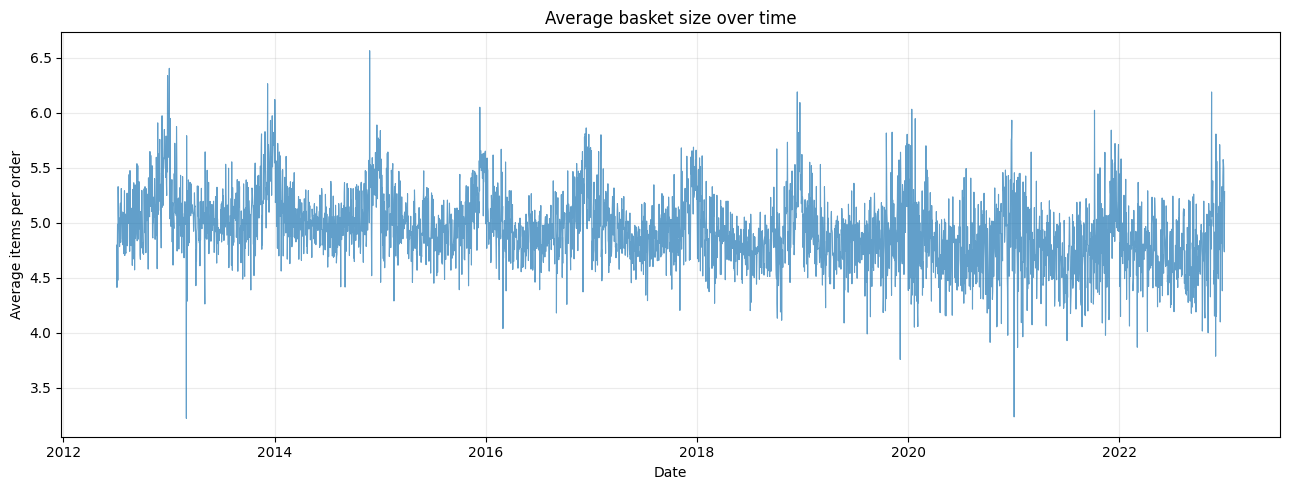

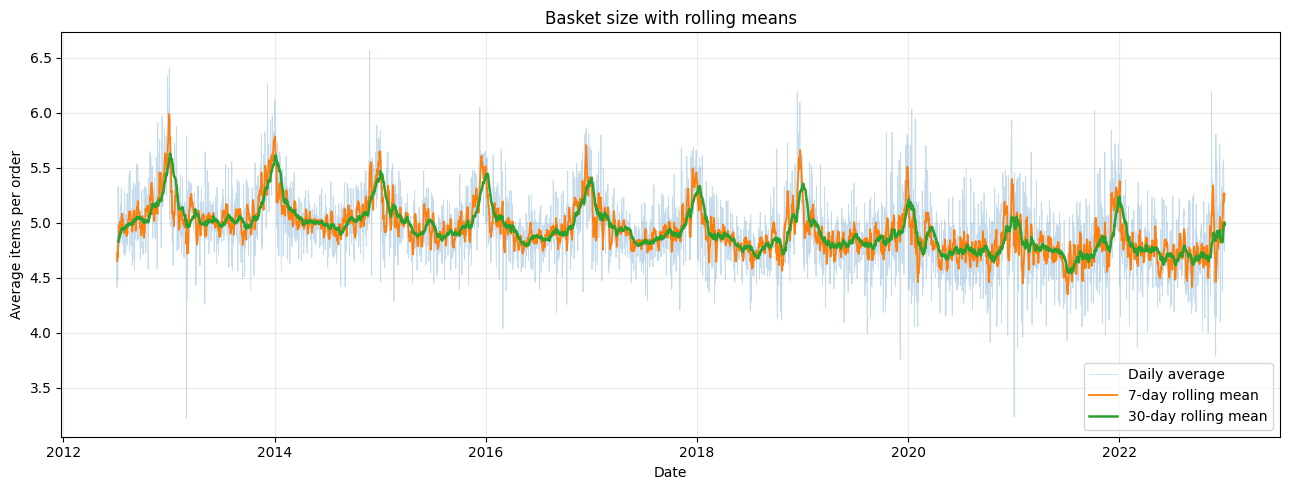

Basket-size trend: decreasing based on 30-day rolling average (4.99 early vs 4.79 recent, -3.9%)


In [8]:
daily_ts = pd.DataFrame()
basket_trend_statement = "not available"

if not order_level.empty:
    valid_orders = order_level.dropna(subset=["order_date"]).copy()
    valid_orders["date"] = valid_orders["order_date"].dt.floor("D")
    valid_orders["large_basket_flag"] = valid_orders[basket_metric_col] >= basket_summary.get("large_basket_threshold_used", np.inf)
    daily_ts = valid_orders.groupby("date").agg(
        order_count=("_order_id", "nunique"),
        total_revenue=("order_revenue", "sum"),
        avg_items_per_order=(basket_metric_col, "mean"),
        median_items_per_order=(basket_metric_col, "median"),
        avg_unique_products_per_order=("unique_products_per_order", "mean"),
        total_items=(basket_metric_col, "sum"),
        large_basket_share=("large_basket_flag", "mean"),
    ).sort_index()
    full_index = pd.date_range(daily_ts.index.min(), daily_ts.index.max(), freq="D")
    missing_dates_count = int(len(full_index.difference(daily_ts.index)))
    daily_ts = daily_ts.reindex(full_index)
    daily_ts.index.name = "date"
    daily_ts[["order_count", "total_revenue", "total_items"]] = daily_ts[["order_count", "total_revenue", "total_items"]].fillna(0)
    daily_ts["large_basket_share"] = daily_ts["large_basket_share"].fillna(0)
    daily_ts["AOV"] = daily_ts["total_revenue"] / daily_ts["order_count"].replace(0, np.nan)
    daily_ts["month_of_year"] = daily_ts.index.month
    daily_ts["quarter"] = daily_ts.index.quarter
    daily_ts["dayofweek"] = daily_ts.index.dayofweek
    daily_ts["weekday_name"] = daily_ts.index.day_name()
    daily_ts["basket_roll_mean_7_descriptive"] = daily_ts["avg_items_per_order"].rolling(7, min_periods=3).mean()
    daily_ts["basket_roll_mean_30_descriptive"] = daily_ts["avg_items_per_order"].rolling(30, min_periods=7).mean()

    display(daily_ts.head(10).reset_index())
    display(daily_ts.tail(10).reset_index())

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(daily_ts.index, daily_ts["avg_items_per_order"], linewidth=0.8, alpha=0.7)
    ax.set_title("Average basket size over time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Average items per order")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(daily_ts.index, daily_ts["avg_items_per_order"], linewidth=0.6, alpha=0.25, label="Daily average")
    ax.plot(daily_ts.index, daily_ts["basket_roll_mean_7_descriptive"], linewidth=1.3, label="7-day rolling mean")
    ax.plot(daily_ts.index, daily_ts["basket_roll_mean_30_descriptive"], linewidth=1.8, label="30-day rolling mean")
    ax.set_title("Basket size with rolling means")
    ax.set_xlabel("Date")
    ax.set_ylabel("Average items per order")
    ax.legend()
    plt.tight_layout()
    plt.show()

    first_window = daily_ts["basket_roll_mean_30_descriptive"].dropna().head(90).mean()
    last_window = daily_ts["basket_roll_mean_30_descriptive"].dropna().tail(90).mean()
    if np.isfinite(first_window) and np.isfinite(last_window) and first_window != 0:
        pct_change = (last_window - first_window) / first_window
        if abs(pct_change) < 0.03:
            basket_trend_statement = f"roughly stable based on 30-day rolling average ({first_window:.2f} early vs {last_window:.2f} recent)"
        elif pct_change > 0:
            basket_trend_statement = f"increasing based on 30-day rolling average ({first_window:.2f} early vs {last_window:.2f} recent, {pct_change:.1%})"
        else:
            basket_trend_statement = f"decreasing based on 30-day rolling average ({first_window:.2f} early vs {last_window:.2f} recent, {pct_change:.1%})"
    print(f"Basket-size trend: {basket_trend_statement}")
else:
    display_warning("Basket size over time skipped because order-level basket data is unavailable.")

## 9. Basket size and revenue relationship

Compare basket size with order revenue, daily revenue, daily order count, and AOV. These are exploratory associations rather than causal claims.

,relationship,correlation
0,daily average basket size vs daily revenue,0.0424
1,daily average basket size vs daily order count,0.1384
2,daily average basket size vs daily AOV,-0.2395
3,order-level basket size vs order revenue,0.4381
4,daily order count vs daily revenue,0.9359
5,daily AOV vs daily revenue,-0.0730


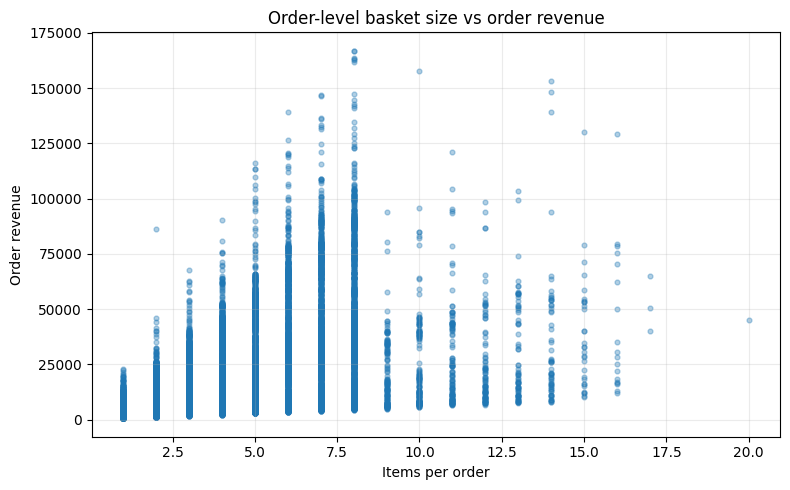

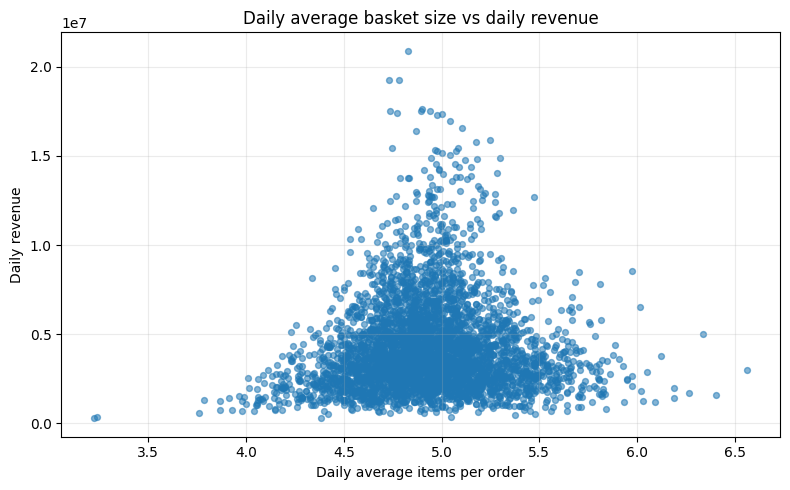

daily revenue appears more associated with order count (corr 0.936) than basket size (corr 0.042)


In [9]:
correlation_table = pd.DataFrame()
basket_revenue_statement = "not available"

if not daily_ts.empty and not valid_baskets.empty:
    corr_rows = [
        {"relationship": "daily average basket size vs daily revenue", "correlation": daily_ts["avg_items_per_order"].corr(daily_ts["total_revenue"])},
        {"relationship": "daily average basket size vs daily order count", "correlation": daily_ts["avg_items_per_order"].corr(daily_ts["order_count"])},
        {"relationship": "daily average basket size vs daily AOV", "correlation": daily_ts["avg_items_per_order"].corr(daily_ts["AOV"])},
        {"relationship": "order-level basket size vs order revenue", "correlation": valid_baskets[basket_metric_col].corr(valid_baskets["order_revenue"])},
        {"relationship": "daily order count vs daily revenue", "correlation": daily_ts["order_count"].corr(daily_ts["total_revenue"])},
        {"relationship": "daily AOV vs daily revenue", "correlation": daily_ts["AOV"].corr(daily_ts["total_revenue"])},
    ]
    correlation_table = pd.DataFrame(corr_rows)
    display(correlation_table)

    basket_corr = correlation_table.loc[correlation_table["relationship"] == "daily average basket size vs daily revenue", "correlation"].iloc[0]
    order_corr = correlation_table.loc[correlation_table["relationship"] == "daily order count vs daily revenue", "correlation"].iloc[0]
    aov_corr = correlation_table.loc[correlation_table["relationship"] == "daily AOV vs daily revenue", "correlation"].iloc[0]
    if abs(basket_corr) > max(abs(order_corr), abs(aov_corr)) + 0.05:
        basket_revenue_statement = f"daily revenue appears most associated with basket size among these signals (corr {basket_corr:.3f})"
    elif abs(order_corr) >= abs(aov_corr):
        basket_revenue_statement = f"daily revenue appears more associated with order count (corr {order_corr:.3f}) than basket size (corr {basket_corr:.3f})"
    else:
        basket_revenue_statement = f"daily revenue appears more associated with AOV (corr {aov_corr:.3f}) than basket size (corr {basket_corr:.3f})"

    sample_orders = valid_baskets.sample(min(len(valid_baskets), 12000), random_state=42)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(sample_orders[basket_metric_col], sample_orders["order_revenue"], alpha=0.35, s=12)
    ax.set_title("Order-level basket size vs order revenue")
    ax.set_xlabel("Items per order")
    ax.set_ylabel("Order revenue")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(daily_ts["avg_items_per_order"], daily_ts["total_revenue"], alpha=0.55, s=18)
    ax.set_title("Daily average basket size vs daily revenue")
    ax.set_xlabel("Daily average items per order")
    ax.set_ylabel("Daily revenue")
    plt.tight_layout()
    plt.show()

    print(basket_revenue_statement)
else:
    display_warning("Basket size and revenue relationship skipped because basket or daily data is unavailable.")

## 10. Basket size by promotion status

Compare promotion/campaign-flagged orders with unflagged orders. Promotion status is approximated from item promo IDs, discounts, and promotion calendar windows when available.

,label,orders,revenue,avg_basket_size,median_basket_size,avg_unique_products,AOV,order_share,revenue_share,item_promo_orders,calendar_window_orders
0,not promotion/campaign flagged,347017,"9,618,199,408.4800",4.9398,5.0000,1.0981,"27,716.7960",0.5364,0.5854,0,0
1,promotion/campaign flagged,299928,"6,812,277,177.0500",4.9977,5.0000,1.1122,"22,713.0417",0.4636,0.4146,248242,299928


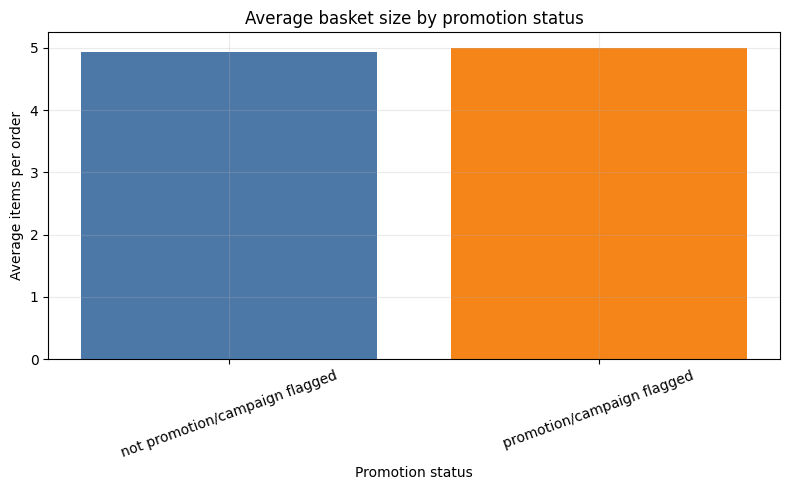

C:\Users\ACER\AppData\Local\Temp\ipykernel_6744\311097733.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=["Not flagged", "Promotion flagged"], showfliers=False)


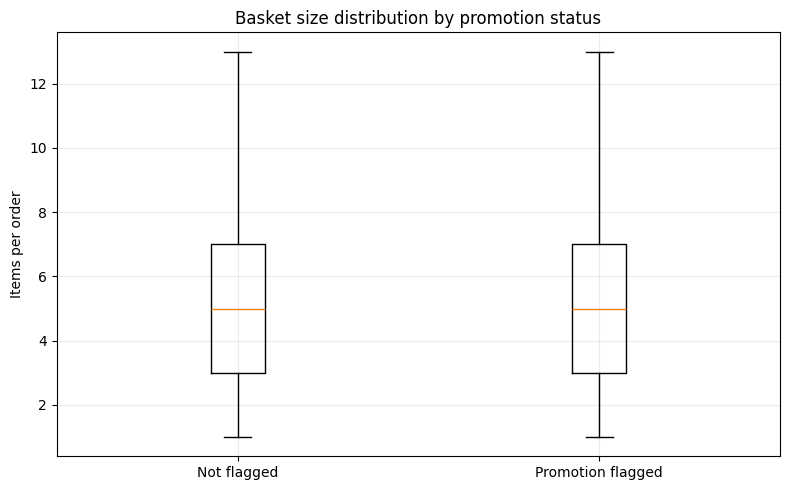

promotion/campaign-flagged orders have average basket size difference 0.06 (1.2%) versus unflagged orders
Interpretation note: this is an association and does not prove promotions caused basket-size differences.


In [10]:
promo_summary = pd.DataFrame()
promo_difference_statement = "not available"

if not order_level.empty and promo_status_available:
    promo_summary = order_level.groupby("is_promo_order").agg(
        orders=("_order_id", "nunique"),
        revenue=("order_revenue", "sum"),
        avg_basket_size=(basket_metric_col, "mean"),
        median_basket_size=(basket_metric_col, "median"),
        avg_unique_products=("unique_products_per_order", "mean"),
        item_promo_orders=("has_item_promo", "sum"),
        calendar_window_orders=("in_promotion_calendar_window", "sum"),
    ).reset_index()
    promo_summary["label"] = np.where(promo_summary["is_promo_order"], "promotion/campaign flagged", "not promotion/campaign flagged")
    promo_summary["AOV"] = promo_summary["revenue"] / promo_summary["orders"].replace(0, np.nan)
    promo_summary["order_share"] = promo_summary["orders"] / promo_summary["orders"].sum()
    promo_summary["revenue_share"] = promo_summary["revenue"] / promo_summary["revenue"].sum()
    display(promo_summary[["label", "orders", "revenue", "avg_basket_size", "median_basket_size", "avg_unique_products", "AOV", "order_share", "revenue_share", "item_promo_orders", "calendar_window_orders"]])

    if promo_summary["is_promo_order"].nunique() == 2:
        promo_true = promo_summary.loc[promo_summary["is_promo_order"] == True].iloc[0]
        promo_false = promo_summary.loc[promo_summary["is_promo_order"] == False].iloc[0]
        diff = promo_true["avg_basket_size"] - promo_false["avg_basket_size"]
        pct = diff / promo_false["avg_basket_size"] if promo_false["avg_basket_size"] else np.nan
        promo_difference_statement = f"promotion/campaign-flagged orders have average basket size difference {diff:.2f} ({pct:.1%}) versus unflagged orders"

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(promo_summary["label"], promo_summary["avg_basket_size"], color=["#4C78A8", "#F58518"])
    ax.set_title("Average basket size by promotion status")
    ax.set_xlabel("Promotion status")
    ax.set_ylabel("Average items per order")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

    box_data = [
        order_level.loc[order_level["is_promo_order"] == False, basket_metric_col].dropna(),
        order_level.loc[order_level["is_promo_order"] == True, basket_metric_col].dropna(),
    ]
    if all(len(x) > 0 for x in box_data):
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.boxplot(box_data, labels=["Not flagged", "Promotion flagged"], showfliers=False)
        ax.set_title("Basket size distribution by promotion status")
        ax.set_ylabel("Items per order")
        plt.tight_layout()
        plt.show()

    print(promo_difference_statement)
    print("Interpretation note: this is an association and does not prove promotions caused basket-size differences.")
else:
    print("Promotion status is unavailable. Basket size by promotion status cannot be evaluated.")

## 11. Basket size seasonality

Analyze whether customers buy more items per order by month of year, weekday, and quarter.

Month-of-year basket seasonality:


,month_of_year,avg_basket_size,median_basket_size,avg_order_count,avg_revenue,days
0,1,5.0440,5.0000,95.0000,"2,591,154.6045",310
1,2,4.9492,5.0000,124.2234,"3,480,800.7782",282
2,3,4.9019,5.0000,185.2903,"4,928,185.4732",310
3,4,4.8553,5.0000,247.7833,"6,532,951.8821",300
4,5,4.8310,5.0000,238.5258,"6,575,416.3495",310
5,6,4.8401,5.0000,240.9000,"6,427,108.6523",300
6,7,4.8255,5.0000,185.7278,"4,659,789.3747",338
7,8,4.8593,5.0000,192.9941,"4,441,193.4900",341
8,9,4.8737,5.0000,148.6485,"3,797,825.6016",330
9,10,4.8972,5.0000,117.0176,"3,302,725.2192",341


Day-of-week basket seasonality:


,dayofweek,weekday_name,avg_basket_size,median_basket_size,avg_order_count,avg_revenue,days
0,0,Monday,4.9400,5.0000,169.9890,"4,311,034.6027",547
1,1,Tuesday,4.9382,5.0000,176.9525,"4,465,102.6433",547
2,2,Wednesday,4.9440,5.0000,184.4270,"4,680,064.8379",548
3,3,Thursday,4.9239,5.0000,177.1989,"4,523,044.0528",548
4,4,Friday,4.9350,5.0000,158.7810,"4,046,389.7347",548
5,5,Saturday,4.9345,5.0000,153.1953,"3,906,580.8389",548
6,6,Sunday,4.9427,5.0000,160.9397,"4,073,853.6848",547


Quarter basket seasonality:


,quarter,avg_basket_size,median_basket_size,avg_order_count,avg_revenue,days
0,1,4.9655,5.0000,135.1674,"3,672,484.7489",902
1,2,4.8420,5.0000,242.3604,"6,512,524.4271",910
2,3,4.8527,5.0000,176.0565,"4,304,002.2173",1009
3,4,5.0807,5.0000,125.3310,"2,814,980.1147",1012


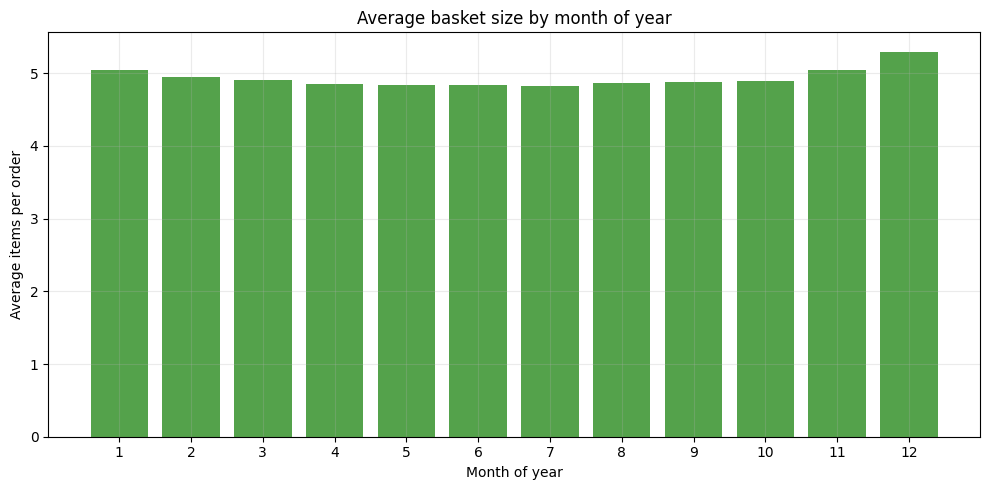

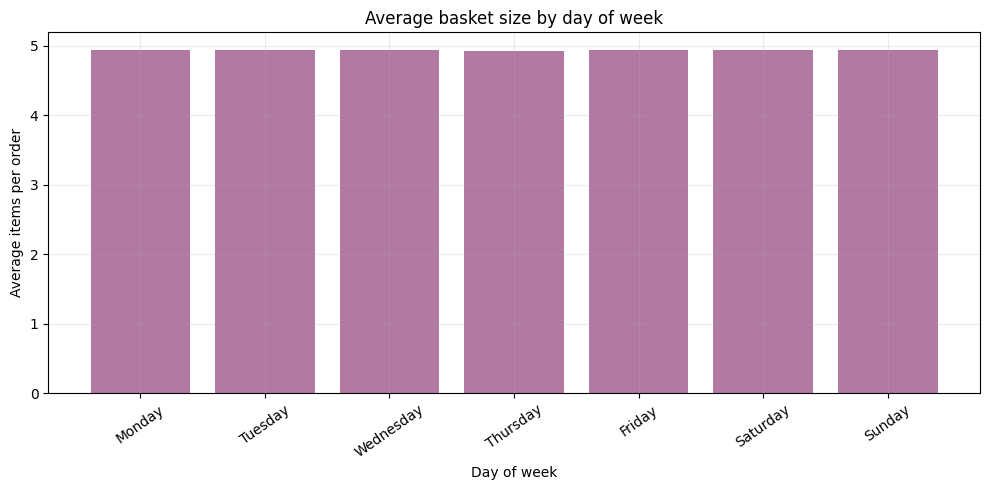

In [11]:
month_seasonality = pd.DataFrame()
dow_seasonality = pd.DataFrame()
quarter_seasonality = pd.DataFrame()

if not daily_ts.empty:
    month_seasonality = daily_ts.groupby("month_of_year").agg(
        avg_basket_size=("avg_items_per_order", "mean"),
        median_basket_size=("median_items_per_order", "median"),
        avg_order_count=("order_count", "mean"),
        avg_revenue=("total_revenue", "mean"),
        days=("order_count", "size"),
    ).reset_index()
    dow_seasonality = daily_ts.groupby(["dayofweek", "weekday_name"]).agg(
        avg_basket_size=("avg_items_per_order", "mean"),
        median_basket_size=("median_items_per_order", "median"),
        avg_order_count=("order_count", "mean"),
        avg_revenue=("total_revenue", "mean"),
        days=("order_count", "size"),
    ).reset_index().sort_values("dayofweek")
    quarter_seasonality = daily_ts.groupby("quarter").agg(
        avg_basket_size=("avg_items_per_order", "mean"),
        median_basket_size=("median_items_per_order", "median"),
        avg_order_count=("order_count", "mean"),
        avg_revenue=("total_revenue", "mean"),
        days=("order_count", "size"),
    ).reset_index()

    print("Month-of-year basket seasonality:")
    display(month_seasonality)
    print("Day-of-week basket seasonality:")
    display(dow_seasonality)
    print("Quarter basket seasonality:")
    display(quarter_seasonality)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(month_seasonality["month_of_year"].astype(str), month_seasonality["avg_basket_size"], color="#54A24B")
    ax.set_title("Average basket size by month of year")
    ax.set_xlabel("Month of year")
    ax.set_ylabel("Average items per order")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(dow_seasonality["weekday_name"], dow_seasonality["avg_basket_size"], color="#B279A2")
    ax.set_title("Average basket size by day of week")
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Average items per order")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()
else:
    display_warning("Basket size seasonality skipped because daily data is unavailable.")

## 12. Basket size by category, if available

For multi-category orders, this section measures basket size for orders containing each category. This is not a causal category effect; it describes baskets associated with category presence.

,category,orders,category_revenue,avg_order_basket_size_for_orders_containing_category,median_order_basket_size_for_orders_containing_category,avg_unique_products_for_orders_containing_category,promo_order_share,category_revenue_share,small_sample_flag
2,Outdoor,200454,"2,494,882,754.2000",5.8990,6.0000,1.3108,0.4958,0.1518,False
0,Casual,23600,"460,648,383.3500",4.6804,5.0000,1.0447,0.4546,0.0280,False
1,GenZ,37054,"343,599,095.3600",4.6066,5.0000,1.0264,0.4551,0.0209,False
3,Streetwear,389543,"13,131,346,352.6200",4.5837,5.0000,1.0197,0.4486,0.7992,False


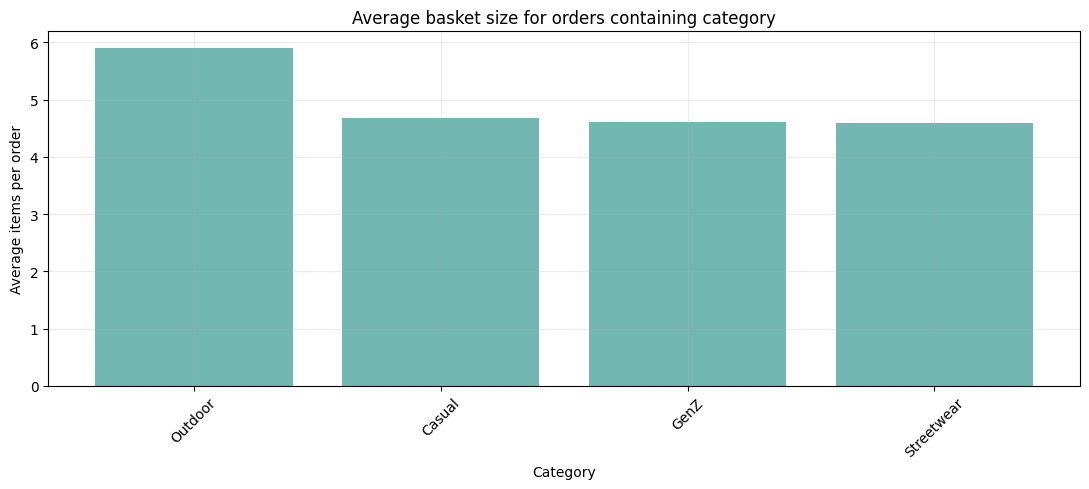

In [12]:
category_summary = pd.DataFrame()

if not category_order.empty and category_col is not None:
    category_summary = category_order.groupby(category_col).agg(
        orders=("_order_id", "nunique"),
        category_revenue=("category_revenue", "sum"),
        avg_order_basket_size_for_orders_containing_category=(basket_metric_col, "mean"),
        median_order_basket_size_for_orders_containing_category=(basket_metric_col, "median"),
        avg_unique_products_for_orders_containing_category=("unique_products_per_order", "mean"),
        promo_order_share=("is_promo_order", "mean"),
    ).reset_index()
    category_summary["category_revenue_share"] = category_summary["category_revenue"] / category_summary["category_revenue"].sum()
    category_summary["small_sample_flag"] = category_summary["orders"] < max(30, category_summary["orders"].median() * 0.1)
    category_summary = category_summary.sort_values("avg_order_basket_size_for_orders_containing_category", ascending=False)
    display(category_summary)

    fig, ax = plt.subplots(figsize=(11, 5))
    plot_df = category_summary.head(20)
    ax.bar(plot_df[category_col].astype(str), plot_df["avg_order_basket_size_for_orders_containing_category"], color="#72B7B2")
    ax.set_title("Average basket size for orders containing category")
    ax.set_xlabel("Category")
    ax.set_ylabel("Average items per order")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Product category data is unavailable or could not be joined. Basket size by category is skipped.")

## 13. Basket-size anomaly checks

Identify unusually large baskets and dates with high large-basket share. Check whether these overlap with high revenue or promotion flags.

,_order_id,order_date,basket_size_quantity,basket_size_lines,unique_products_per_order,order_revenue,is_promo_order
461054,594591,2018-05-30,31,5,5,"121,587.7500",False
62008,79991,2013-05-26,27,4,4,"42,526.8300",False
453781,585205,2018-05-09,26,4,4,"139,286.1000",False
139815,180502,2014-05-19,25,4,4,"44,451.2500",False
25178,32586,2012-12-01,25,4,4,"28,554.7000",False
187451,241805,2014-12-29,24,3,3,"35,664.7200",True
193037,249048,2015-01-31,24,4,4,"32,606.3600",True
166814,215223,2014-08-30,24,3,3,"81,055.6000",True
265223,342038,2015-11-27,24,4,4,"18,404.5300",True
204401,263667,2015-03-31,24,4,4,"58,771.2900",True


,date,order_count,total_revenue,avg_items_per_order,median_items_per_order,large_basket_share
0,2020-12-03,25,"528,608.4800",5.4800,5.0000,0.0800
1,2013-11-17,104,"2,416,530.1500",5.8077,6.0000,0.0673
2,2018-12-19,78,"1,548,668.1900",5.8205,5.0000,0.0641
3,2018-01-04,48,"1,209,588.0000",5.3333,5.0000,0.0625
4,2019-10-18,49,"1,653,633.2600",5.8163,5.0000,0.0612
5,2021-02-02,35,"958,876.9000",5.3714,5.0000,0.0571
6,2017-01-12,92,"2,704,158.2100",5.1087,5.0000,0.0543
7,2013-12-18,231,"3,189,533.3600",5.9307,5.0000,0.0519
8,2014-01-12,79,"2,172,729.2900",5.7215,5.0000,0.0506
9,2015-12-15,198,"3,089,177.6300",5.6566,5.0000,0.0505


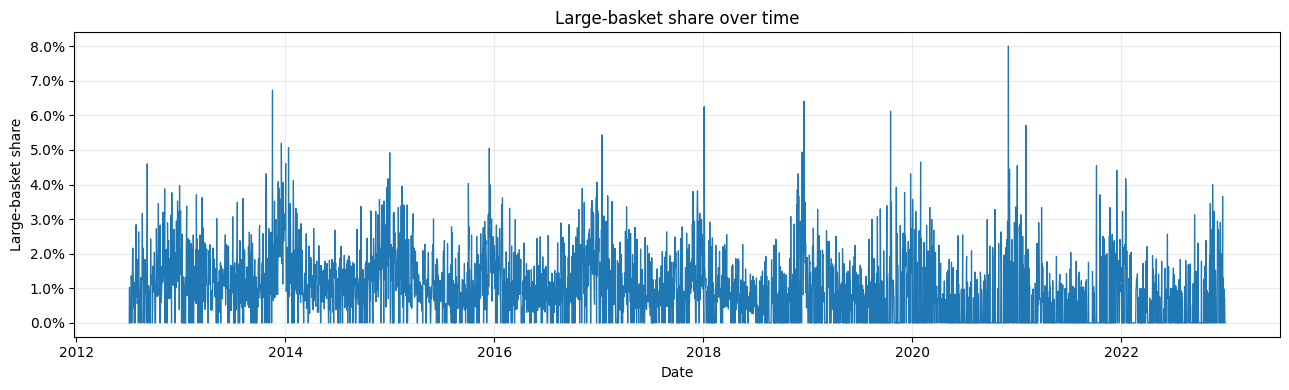

6,797 orders meet the large-basket threshold (14.00); promotion-flag share among them is 50.8%


In [13]:
large_basket_orders = pd.DataFrame()
large_basket_days = pd.DataFrame()
anomaly_statement = "not available"

if not valid_baskets.empty:
    threshold = basket_summary.get("large_basket_threshold_used", valid_baskets[basket_metric_col].quantile(0.99))
    large_basket_orders = valid_baskets[valid_baskets[basket_metric_col] >= threshold].sort_values(basket_metric_col, ascending=False)
    display(large_basket_orders[["_order_id", "order_date", basket_metric_col, "basket_size_lines", "unique_products_per_order", "order_revenue", "is_promo_order"]].head(25))

    if not daily_ts.empty:
        large_basket_days = daily_ts.sort_values(["large_basket_share", "avg_items_per_order"], ascending=False).head(20).reset_index()
        display(large_basket_days[["date", "order_count", "total_revenue", "avg_items_per_order", "median_items_per_order", "large_basket_share"]])

        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(daily_ts.index, daily_ts["large_basket_share"], linewidth=0.9)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_title("Large-basket share over time")
        ax.set_xlabel("Date")
        ax.set_ylabel("Large-basket share")
        plt.tight_layout()
        plt.show()

    if not large_basket_orders.empty:
        promo_share = large_basket_orders["is_promo_order"].mean() if "is_promo_order" in large_basket_orders.columns else np.nan
        anomaly_statement = f"{len(large_basket_orders):,} orders meet the large-basket threshold ({threshold:.2f}); promotion-flag share among them is {promo_share:.1%}" if np.isfinite(promo_share) else f"{len(large_basket_orders):,} orders meet the large-basket threshold ({threshold:.2f})"
    else:
        anomaly_statement = "no orders met the configured large-basket threshold"
    print(anomaly_statement)
else:
    display_warning("Basket-size anomaly checks skipped because basket data is unavailable.")

## 14. Leakage-safe basket-size forecast feature preview

Daily basket-size forecast candidates are shifted before lagging or rolling. Future basket size must not be used directly unless separately forecasted.

In [14]:
basket_features = pd.DataFrame()

if not daily_ts.empty:
    basket_features = pd.DataFrame(index=daily_ts.index)
    basket_features["total_revenue"] = daily_ts["total_revenue"]
    basket_features["order_count"] = daily_ts["order_count"]
    basket_features["avg_items_per_order"] = daily_ts["avg_items_per_order"]
    basket_features["median_items_per_order"] = daily_ts["median_items_per_order"]
    basket_features["avg_unique_products_per_order"] = daily_ts["avg_unique_products_per_order"]

    shifted_basket = daily_ts["avg_items_per_order"].shift(1)
    shifted_large_share = daily_ts["large_basket_share"].shift(1)
    basket_features["avg_items_per_order_lag_1"] = daily_ts["avg_items_per_order"].shift(1)
    basket_features["avg_items_per_order_lag_7"] = daily_ts["avg_items_per_order"].shift(7)
    basket_features["avg_items_per_order_lag_30"] = daily_ts["avg_items_per_order"].shift(30)
    basket_features["basket_size_roll_mean_7"] = shifted_basket.rolling(7, min_periods=3).mean()
    basket_features["basket_size_roll_mean_30"] = shifted_basket.rolling(30, min_periods=7).mean()
    basket_features["basket_size_roll_std_30"] = shifted_basket.rolling(30, min_periods=7).std()
    basket_features["large_basket_share_lag_30"] = shifted_large_share.rolling(30, min_periods=7).mean()
    basket_features = basket_features.reset_index().rename(columns={"index": "date"})
    print("Feature preview. Lag and rolling basket-size features are shifted so date t uses only dates before t.")
    display(basket_features.head(40))
else:
    display_warning("Leakage-safe basket-size feature preview skipped because daily data is unavailable.")

Feature preview. Lag and rolling basket-size features are shifted so date t uses only dates before t.


,date,total_revenue,order_count,avg_items_per_order,median_items_per_order,avg_unique_products_per_order,avg_items_per_order_lag_1,avg_items_per_order_lag_7,avg_items_per_order_lag_30,basket_size_roll_mean_7,basket_size_roll_mean_30,basket_size_roll_std_30,large_basket_share_lag_30
0,2012-07-04,"5,123,547.9400",162,4.7963,5.0000,1.0741,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",97,4.4124,4.0000,1.0619,4.7963,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,"3,054,029.4200",93,4.7419,5.0000,1.0645,4.4124,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,"2,667,930.9400",73,4.9863,5.0000,1.0274,4.7419,NaN,NaN,4.6502,NaN,NaN,NaN
4,2012-07-08,"2,360,851.9000",88,4.4773,4.0000,1.0682,4.9863,NaN,NaN,4.7342,NaN,NaN,NaN
5,2012-07-09,"3,548,386.4600",137,5.3285,5.0000,1.1460,4.4773,NaN,NaN,4.6828,NaN,NaN,NaN
6,2012-07-10,"5,234,938.6200",183,5.0710,5.0000,1.1093,5.3285,NaN,NaN,4.7904,NaN,NaN,NaN
7,2012-07-11,"5,582,884.7800",221,4.9638,5.0000,1.0995,5.0710,4.7963,NaN,4.8305,4.8305,0.3263,0.0033
8,2012-07-12,"5,734,632.0200",246,5.0447,5.0000,1.1179,4.9638,4.4124,NaN,4.8545,4.8472,0.3057,0.0046
9,2012-07-13,"5,309,511.7100",201,4.9502,5.0000,1.1095,5.0447,4.7419,NaN,4.9448,4.8691,0.2935,0.0054


## 15. Key observations and warnings

The final summary reports average and median items per order, common basket sizes, trend direction, revenue association, promotion differences, seasonality, large-basket anomalies, and leakage-safe feature recommendations.

In [15]:
print("Concise insight summary")
print("=" * 80)

if basket_summary:
    print(f"Basket-size definition: {basket_summary['basket_size_definition']}.")
    print(f"Average items per order: {basket_summary['average_items_per_order']:.2f}.")
    print(f"Median items per order: {basket_summary['median_items_per_order']:.2f}.")
    common_text = "; ".join(f"{int(row.basket_size)} items ({row.order_share:.1%})" for row in common_basket_sizes.sort_values("orders", ascending=False).head(5).itertuples(index=False))
    print(f"Common basket sizes: {common_text}.")
else:
    print("Basket-size summary: not available.")

print(f"Basket size over time: {basket_trend_statement}.")
print(f"Basket size and revenue relationship: {basket_revenue_statement}.")

if not promo_summary.empty:
    print(f"Basket size by promotion status: {promo_difference_statement}.")
else:
    print("Basket size by promotion status: not available.")

if not month_seasonality.empty:
    high_month = month_seasonality.sort_values("avg_basket_size", ascending=False).iloc[0]
    low_month = month_seasonality.sort_values("avg_basket_size", ascending=True).iloc[0]
    print(f"Highest average basket-size month: {int(high_month.month_of_year)} ({high_month.avg_basket_size:.2f}).")
    print(f"Lowest average basket-size month: {int(low_month.month_of_year)} ({low_month.avg_basket_size:.2f}).")
if not dow_seasonality.empty:
    high_dow = dow_seasonality.sort_values("avg_basket_size", ascending=False).iloc[0]
    low_dow = dow_seasonality.sort_values("avg_basket_size", ascending=True).iloc[0]
    print(f"Highest average basket-size weekday: {high_dow.weekday_name} ({high_dow.avg_basket_size:.2f}).")
    print(f"Lowest average basket-size weekday: {low_dow.weekday_name} ({low_dow.avg_basket_size:.2f}).")

if not large_basket_orders.empty:
    top_large = large_basket_orders.head(5)
    text = "; ".join(
        f"{row['_order_id']} on {row['order_date'].date()} ({row[basket_metric_col]:.0f} items, revenue {row['order_revenue']:,.2f})"
        for row in top_large.to_dict("records")
    )
    print(f"Unusually large basket orders: {text}.")
    print(f"Large-basket anomaly note: {anomaly_statement}.")
else:
    print("Unusually large basket orders: none flagged by the configured threshold.")

recommended_features = [
    "avg_items_per_order_lag_1",
    "avg_items_per_order_lag_7",
    "avg_items_per_order_lag_30",
    "basket_size_roll_mean_7",
    "basket_size_roll_mean_30",
    "basket_size_roll_std_30",
    "large_basket_share_lag_30",
]
print("Recommended leakage-safe basket-size forecast features: " + ", ".join(recommended_features) + ".")

quality_warnings = []
if quality:
    if quality.get("orders_without_item_rows", 0):
        quality_warnings.append(f"{quality['orders_without_item_rows']:,} orders without item rows")
    if quality.get("orders_with_missing_quantity_rows", 0):
        quality_warnings.append(f"{quality['orders_with_missing_quantity_rows']:,} orders with missing quantity rows")
    if quality.get("orders_with_zero_or_negative_basket_size", 0):
        quality_warnings.append(f"{quality['orders_with_zero_or_negative_basket_size']:,} orders with zero or negative basket size")
    if quality.get("orders_with_missing_revenue", 0):
        quality_warnings.append(f"{quality['orders_with_missing_revenue']:,} orders with missing revenue")
    if not quality.get("promotion_status_available", False):
        quality_warnings.append("promotion status unavailable")
print("Data quality warnings: " + ("; ".join(quality_warnings) if quality_warnings else "none material for detected fields") + ".")
print("Forecasting warning: future basket size must not be used directly as a revenue feature unless basket size is separately forecasted. The feature preview shifts before rolling or lagging.")
print("Interpretation warning: promotion, category, and seasonality differences are exploratory associations, not causal conclusions.")

Concise insight summary
Basket-size definition: sum of item quantity from quantity.
Average items per order: 4.97.
Median items per order: 5.00.
Common basket sizes: 8 items (12.2%); 7 items (12.2%); 6 items (12.0%); 5 items (11.9%); 4 items (11.7%).
Basket size over time: decreasing based on 30-day rolling average (4.99 early vs 4.79 recent, -3.9%).
Basket size and revenue relationship: daily revenue appears more associated with order count (corr 0.936) than basket size (corr 0.042).
Basket size by promotion status: promotion/campaign-flagged orders have average basket size difference 0.06 (1.2%) versus unflagged orders.
Highest average basket-size month: 12 (5.30).
Lowest average basket-size month: 7 (4.83).
Highest average basket-size weekday: Wednesday (4.94).
Lowest average basket-size weekday: Thursday (4.92).
Unusually large basket orders: 594591 on 2018-05-30 (31 items, revenue 121,587.75); 79991 on 2013-05-26 (27 items, revenue 42,526.83); 585205 on 2018-05-09 (26 items, reven